## ML&Fintech HW9 Chapter 7 Q6

Name: Alvin B. Lin\
ID: 112652040\
Date: 24/11/2025\
HW #: 9

6.In this exercise, you will further analyze the `Wage` data set considered throughout this chapter.

In [26]:
from ISLP import load_data
import pandas as pd

Wage = load_data('Wage')
Wage['age'] = pd.to_numeric(Wage['age'], errors='coerce')

In [2]:
Wage.head(10)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
5,2008,54,2. Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.845098,127.115744
6,2009,44,2. Married,4. Other,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.133021,169.528538
7,2008,30,1. Never Married,3. Asian,3. Some College,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.716003,111.720849
8,2006,41,1. Never Married,2. Black,3. Some College,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.778151,118.884359
9,2004,52,2. Married,1. White,2. HS Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.857332,128.680488


In [4]:
Wage.describe()

,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


(a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

Text(0, 0.5, 'Wage')

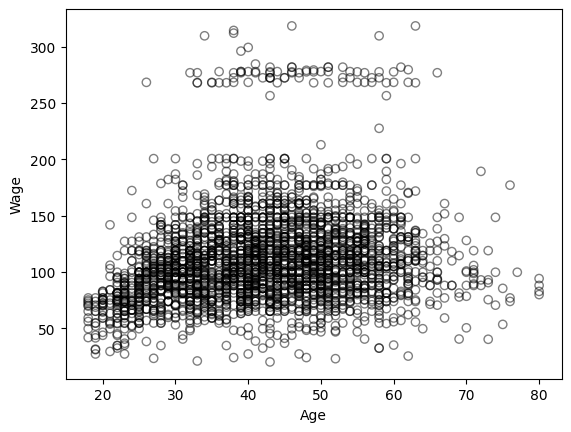

In [27]:
x = Wage['age']
Wage['age'] = pd.to_numeric(Wage['age'], errors='coerce')
y = pd.to_numeric(Wage['wage'], errors='coerce') # Assuming 'y' is the wage column

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import sklearn.linear_model as lm
from sklearn.preprocessing import PolynomialFeatures
import sklearn.model_selection as ms

plt.scatter(x, y, facecolor='None', edgecolor='k', alpha=0.5)
plt.xlabel('Age')
plt.ylabel('Wage')

Best degree: 4


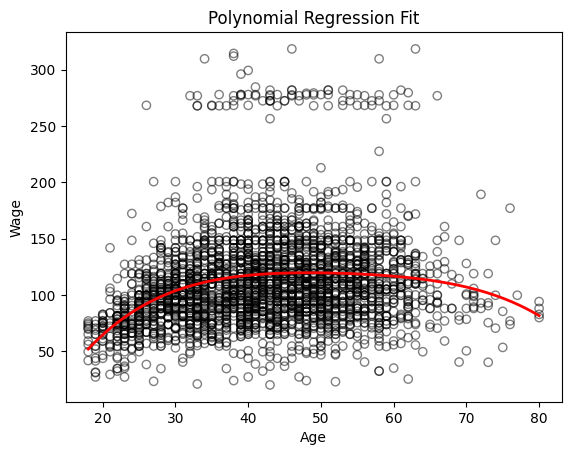

In [28]:
# use cross validation in sklearn to choose degree of polynomial
degrees = np.arange(1, 11)
mse_list = []
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    x_poly = poly.fit_transform(x.values.reshape(-1, 1))
    model = lm.LinearRegression()
    neg_mse = ms.cross_val_score(model, x_poly, y, scoring='neg_mean_squared_error', cv=10)
    mse = -neg_mse.mean()
    mse_list.append(mse)
best_degree = degrees[np.argmin(mse_list)]
print(f'Best degree: {best_degree}')
# fit the best model
poly = PolynomialFeatures(degree=best_degree)
x_poly = poly.fit_transform(x.values.reshape(-1, 1))
model = lm.LinearRegression()
model.fit(x_poly, y)
x_range = np.linspace(x.min(), x.max(), 100)
x_range_poly = poly.transform(x_range.reshape(-1, 1))
y_pred = model.predict(x_range_poly)
plt.scatter(x, y, facecolor='None', edgecolor='k', alpha=0.5)
plt.plot(x_range, y_pred, color='r', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Polynomial Regression Fit')
plt.show()


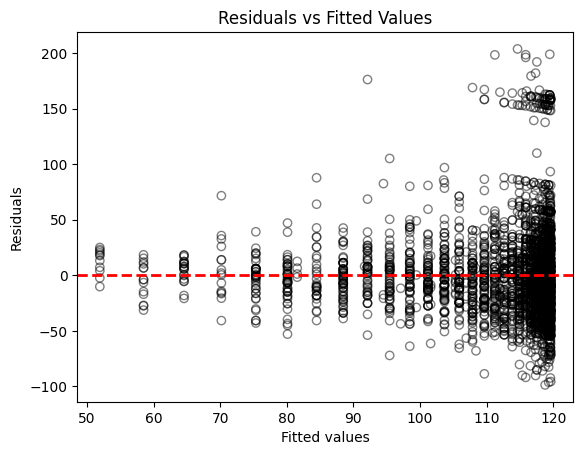

In [14]:
# plot the residuals
y_fit = model.predict(x_poly)
residuals = y - y_fit
plt.scatter(y_fit, residuals, facecolor='None', edgecolor='k', alpha=0.5)
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

In [29]:
type(y)

pandas.core.series.Series

(b) Fit a step function to predict wage using age, and perform crossvalidation to choose the optimal number of cuts. Make a plot of the fit obtained.

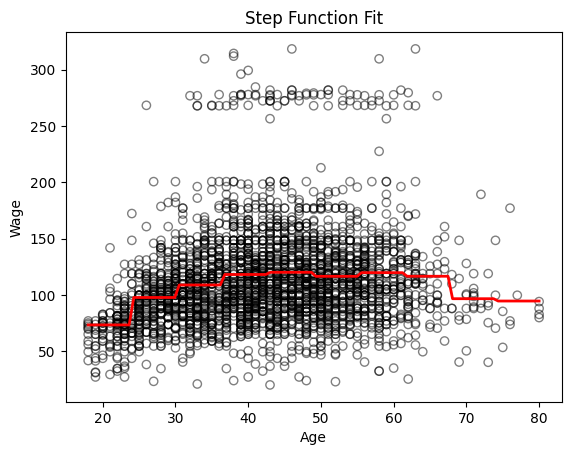

In [39]:
Wage['age_cut'] = pd.cut(Wage['age'], bins=10)
age_dummies = pd.get_dummies(Wage['age_cut'], drop_first=True, dtype=int)
X_stage = age_dummies

# FIX 2: Ensure the data used for the OLS model has consistent indices
# If you dropped NaNs in Wage, ensure 'y' aligns with the remaining indices
# Assuming y is a pandas Series with a matching index to Wage:
y_aligned = y.reindex(Wage.index) 

# The OLS model fitting should now work
model_stage = sm.OLS(y_aligned, sm.add_constant(X_stage)).fit()

# The rest of the plotting code (ensure 'x' used here aligns with 'Wage' data as well)
x = Wage['age'] # Ensure 'x' is updated to match the cleaned 'Wage' DataFrame
x_range = np.linspace(x.min(), x.max(), 100)
x_range_cut = pd.cut(x_range, bins=10)
x_range_dummies = pd.get_dummies(x_range_cut, drop_first=True, dtype=int)
x_range_dummies = x_range_dummies.reindex(columns=age_dummies.columns, fill_value=0)
y_stage_pred = model_stage.predict(sm.add_constant(x_range_dummies))

plt.scatter(x, y_aligned, facecolor='None', edgecolor='k', alpha=0.5)
plt.plot(x_range, y_stage_pred, color='r', linewidth=2)
plt.xlabel('Age')
plt.ylabel('Wage')
plt.title('Step Function Fit')
plt.show()